# 📊 Análise de Dados — Instagram Analytics

**Dataset:** `Instagram_data.csv`  
**Objetivo:** Análise exploratória completa cobrindo as etapas de Data Engineering, Data Science e Analytics.

---

## Etapas
1. Configuração do Ambiente
2. Leitura e Inspeção Inicial
3. Qualidade dos Dados (Nulls, Duplicatas, Tipos)
4. Estatísticas Descritivas
5. Detecção de Outliers
6. Análise de Distribuição
7. Correlações
8. Análise de Texto (Caption e Hashtags)
9. Engenharia de Features
10. Insights e Conclusões

---
## 1. ⚙️ Configuração do Ambiente

In [240]:
# Instalação de bibliotecas extras
!pip install -q wordcloud missingno

In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
from wordcloud import WordCloud
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('✅ Ambiente configurado com sucesso!')

✅ Ambiente configurado com sucesso!


---
## 2. 📂 Leitura e Inspeção Inicial

In [242]:
df = pd.read_csv('/content/Instagram_data.csv', encoding='latin1')
# Substituir 'amankharwal' por 'suasaladatech' em todo o dataset
df = df.replace('amankharwal', 'suasaladatech', regex=True)

# Verificar se ainda existe alguma ocorrência
#ocorrencias = df.apply(lambda col: col.astype(str).str.contains('amankharwal', case=False)).sum().sum()
#print(f'Ocorrências restantes de "amankharwal": {ocorrencias}')

# Confirmar a substituição
#ocorrencias_novas = df.apply(lambda col: col.astype(str).str.contains('suasaladatech', case=False)).sum().sum()
print(f'Ocorrências de "suasaladatech": {ocorrencias_novas}')
print(f'✅ Arquivo carregado com sucesso!')
print(f'   Linhas  : {df.shape[0]}')
print(f'   Colunas : {df.shape[1]}')

Ocorrências de "suasaladatech": 117
✅ Arquivo carregado com sucesso!
   Linhas  : 119
   Colunas : 13


In [243]:
# Primeiras linhas
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...
3,4528,2700,621,932,73,172,10,7,213,23,8,Heres how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...


In [244]:
# Últimas linhas
df.tail()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
114,13700,5185,3041,5352,77,573,2,38,373,73,80,Here are some of the best data science certifi...,#datascience #datasciencejobs #datasciencetrai...
115,5731,1923,1368,2266,65,135,4,1,148,20,18,Clustering is a machine learning technique use...,#machinelearning #machinelearningalgorithms #d...
116,4139,1133,1538,1367,33,36,0,1,92,34,10,Clustering music genres is a task of grouping ...,#machinelearning #machinelearningalgorithms #d...
117,32695,11815,3147,17414,170,1095,2,75,549,148,214,Here are some of the best data science certifi...,#datascience #datasciencejobs #datasciencetrai...
118,36919,13473,4176,16444,2547,653,5,26,443,611,228,175 Python Projects with Source Code solved an...,#python #pythonprogramming #pythonprojects #py...


In [245]:
# Tipos de dados e informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Impressions     119 non-null    int64 
 1   From Home       119 non-null    int64 
 2   From Hashtags   119 non-null    int64 
 3   From Explore    119 non-null    int64 
 4   From Other      119 non-null    int64 
 5   Saves           119 non-null    int64 
 6   Comments        119 non-null    int64 
 7   Shares          119 non-null    int64 
 8   Likes           119 non-null    int64 
 9   Profile Visits  119 non-null    int64 
 10  Follows         119 non-null    int64 
 11  Caption         119 non-null    object
 12  Hashtags        119 non-null    object
dtypes: int64(11), object(2)
memory usage: 12.2+ KB


In [246]:
# Lista de colunas
print('Colunas do dataset:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col} ({df[col].dtype})')

Colunas do dataset:
   1. Impressions (int64)
   2. From Home (int64)
   3. From Hashtags (int64)
   4. From Explore (int64)
   5. From Other (int64)
   6. Saves (int64)
   7. Comments (int64)
   8. Shares (int64)
   9. Likes (int64)
  10. Profile Visits (int64)
  11. Follows (int64)
  12. Caption (object)
  13. Hashtags (object)


---
## 3. 🔍 Qualidade dos Dados

### 3.1 Valores Nulos

In [247]:
# Contagem e percentual de nulos por coluna
nulls = pd.DataFrame({
    'Total Nulos'     : df.isnull().sum(),
    'Percentual (%)' : (df.isnull().sum() / len(df) * 100).round(2)
})
nulls = nulls[nulls['Total Nulos'] > 0]

if nulls.empty:
    print('✅ Nenhum valor nulo encontrado no dataset!')
else:
    display(nulls)

✅ Nenhum valor nulo encontrado no dataset!


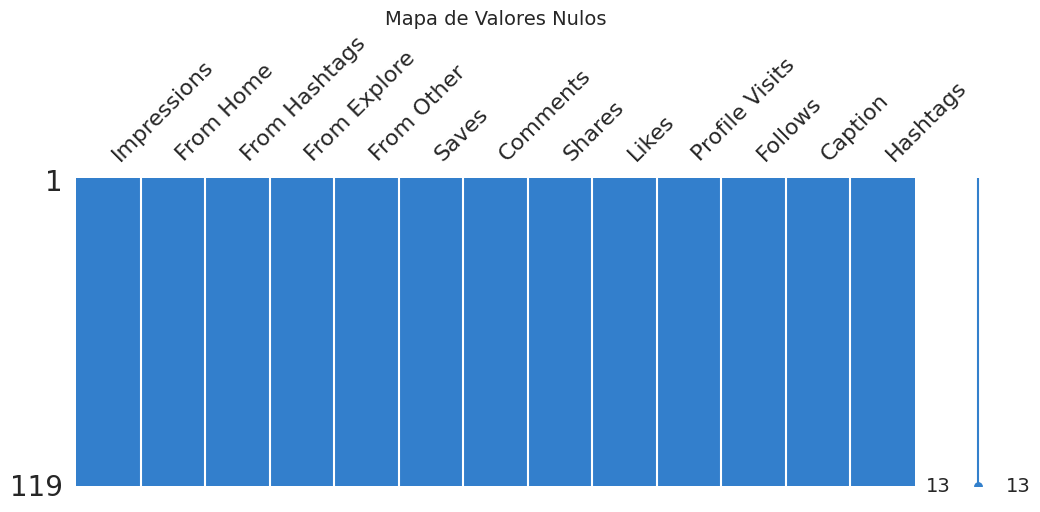

In [248]:
# Mapa visual de nulos
msno.matrix(df, figsize=(12, 4), color=(0.2, 0.5, 0.8))
plt.title('Mapa de Valores Nulos', fontsize=14)
plt.show()

In [249]:
# Duplicatas considerando TODAS as colunas (padrão)
print(f"soma de duplicadas: {df.duplicated().sum()}")

# Duplicatas considerando apenas colunas numéricas
df.duplicated(subset=['Impressions', 'Likes', 'Saves', 'Comments']).sum()
print(f"soma de duplicadas colunas numéricas: {df.duplicated(subset=['Impressions', 'Likes', 'Saves', 'Comments']).sum()}")

# Duplicatas considerando apenas o Caption
df.duplicated(subset=['Caption']).sum()
print(f"soma de duplicadas com o Caption: {df.duplicated(subset=['Caption']).sum()}")


soma de duplicadas: 17
soma de duplicadas colunas numéricas: 17
soma de duplicadas com o Caption: 29


In [250]:
repetidos = df['Caption'].value_counts()
repetidos = repetidos[repetidos > 1]
print(f'Captions que se repetem: {len(repetidos)}')
print(f'Total de posts envolvidos: {repetidos.sum()}')

Captions que se repetem: 27
Total de posts envolvidos: 56


In [251]:

display(repetidos)

,count
Caption,
Here are some of the best data science project ideas on healthcare. If you want to become a data science professional in the healthcare domain then you must try to work on these projects.,3
Here are some of the best websites that you can follow to learn everything in data science.,3
"Stress, anxiety, and depression are threatening the mental health of people. Every person has a reason for having a stressful life. People often share their feelings on social media platforms like on Instagram in the form of posts and stories, and on Reddit in the form of asking for suggestions about their life on subreddits. In the past few years, many content creators have come forward to create content to help people with their mental health. Many organizations can use stress detection to find which social media users are stressed to help them quickly. So if you want to learn how to use machine learning to detect stress on social media posts, this data science project is for you. Detection of stress from social media posts with machine learning using Python: Link in Bio.",2
Data Science Use Cases: Heres how Zomato is using your data for its future business model.,2
"Deep Learning is a subset of machine learning. If you want to become a machine learning engineer, you should know everything about deep learning. If you are looking for some of the best free resources to learn deep learning then here are the two best free resources to learn deep learning.",2
Here are all the programming languages that Google uses in the Front-end and the back-end of Google.,2
Deep learning is a subset of machine learning in which we use artificial neural networks to train models to solve complex problems where we need a large amount of data compared to other machine learning algorithms. Here are some of the best deep learning project ideas that you must try.,2
"In Data Science, Time Series Analysis is a method of analyzing data collected over an interval of time. Stock price data and covid-19 cases data are examples of time-series data. Time Series Analysis helps understand the underlying causes of trends and patterns at particular time intervals. So it is one of the topics that every data scientist should know perfectly. So if you are looking for some of the best books to learn Time Series Analysis, you can choose any one among these books.",2
"In Data Science, Time Series Analysis is a method of analyzing data collected over an interval of time. Stock price data and covid-19 cases data are examples of time-series data. Time Series Analysis helps understand the underlying causes of trends and patterns at particular time intervals. So it is one of the topics that every data scientist should know perfectly. So if you are looking for some of the best data science project ideas on Time Series Analysis, you should try to work on these projects.",2


In [252]:
# Ver as linhas duplicadas
df[df.duplicated(keep=False)]

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
15,5055,2017,2351,298,108,101,7,11,159,17,6,"In Data Science, Time Series Analysis is a met...",#timeseries #time #statistics #datascience #bi...
16,4002,3401,278,128,73,111,17,18,205,16,2,Here are some of the highest paying skills in ...,#career #job #jobs #jobsearch #education #busi...
17,3169,1979,707,341,32,106,8,1,121,21,2,"In Data Science, Time Series Analysis is a met...",#timeseries #time #statistics #datascience #bi...
18,6168,2177,3450,153,296,82,6,6,151,77,30,"Stress, anxiety, and depression are threatenin...",#data #datascience #dataanalysis #dataanalytic...
19,2407,1338,655,276,39,40,8,20,72,10,0,Data Science Use Cases: Heres how Zomato is u...,#data #datascience #dataanalysis #dataanalytic...
23,3052,2608,201,121,87,63,5,14,129,14,2,Here are all the programming languages that Go...,#programming #coding #programmer #python #deve...
24,4628,2406,1260,861,26,144,8,3,160,10,4,Deep Learning is a subset of machine learning....,#deeplearning #machinelearning #artificialinte...
25,4082,2195,1248,541,36,135,11,5,175,19,6,Deep learning is a subset of machine learning ...,#deeplearning #machinelearning #artificialinte...
26,5394,2275,2975,45,65,61,19,6,147,69,6,You must have heard or invested in any cryptoc...,#data #datascience #dataanalysis #dataanalytic...
27,2766,2541,116,51,9,40,10,4,114,11,6,Here are all the programming languages that Fa...,#programming #coding #programmer #python #deve...


### 3.2 Duplicatas

In [253]:
duplicatas = df.duplicated().sum()
print(f'Total de linhas duplicadas: {duplicatas}')

if duplicatas > 0:
    print('\nLinhas duplicadas:')
    display(df[df.duplicated()])
    df = df.drop_duplicates()
    print(f'\n✅ Duplicatas removidas. Novo shape: {df.shape}')
else:
    print('✅ Nenhuma duplicata encontrada!')

Total de linhas duplicadas: 17

Linhas duplicadas:


,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
82,5055,2017,2351,298,108,101,7,11,159,17,6,"In Data Science, Time Series Analysis is a met...",#timeseries #time #statistics #datascience #bi...
83,4002,3401,278,128,73,111,17,18,205,16,2,Here are some of the highest paying skills in ...,#career #job #jobs #jobsearch #education #busi...
84,3169,1979,707,341,32,106,8,1,121,21,2,"In Data Science, Time Series Analysis is a met...",#timeseries #time #statistics #datascience #bi...
85,6168,2177,3450,153,296,82,6,6,151,77,30,"Stress, anxiety, and depression are threatenin...",#data #datascience #dataanalysis #dataanalytic...
86,2407,1338,655,276,39,40,8,20,72,10,0,Data Science Use Cases: Heres how Zomato is u...,#data #datascience #dataanalysis #dataanalytic...
87,3630,1747,1693,72,86,137,4,10,137,14,4,Here are some of the best data analysis projec...,#data #datascience #dataanalysis #dataanalytic...
88,2826,2108,583,76,34,67,3,3,114,30,4,Visualizing data is one of the most valuable s...,#dataanalytics #datascience #data #machinelear...
89,7407,2782,1938,2237,226,288,5,15,263,39,18,Here are some of the most important machine le...,#data #datascience #dataanalysis #dataanalytic...
90,10386,4137,3551,2355,205,668,8,41,328,42,38,Here are some of the best websites that you ca...,#data #datascience #dataanalysis #dataanalytic...
91,2998,1945,794,84,139,42,4,1,126,31,10,Time series analysis means analyzing and findi...,#timeseries #time #statistics #datascience #bi...



✅ Duplicatas removidas. Novo shape: (102, 13)


### 3.3 Verificação de Tipos

In [254]:
# Colunas numéricas e categóricas
cols_num = df.select_dtypes(include=[np.number]).columns.tolist()
cols_txt = df.select_dtypes(include=['object']).columns.tolist()

print(f'Colunas numéricas  ({len(cols_num)}): {cols_num}')
print(f'Colunas texto      ({len(cols_txt)}): {cols_txt}')

Colunas numéricas  (11): ['Impressions', 'From Home', 'From Hashtags', 'From Explore', 'From Other', 'Saves', 'Comments', 'Shares', 'Likes', 'Profile Visits', 'Follows']
Colunas texto      (2): ['Caption', 'Hashtags']


In [255]:
# Recriar features caso ainda não existam no df
if 'caption_length' not in df.columns:
    df['caption_length'] = df['Caption'].astype(str).apply(len)

if 'num_hashtags' not in df.columns:
    df['num_hashtags'] = df['Hashtags'].astype(str).apply(
        lambda x: len([t for t in x.split() if t.startswith('#')])
    )

if 'engagement_rate' not in df.columns:
    df['engagement_rate'] = (
        (df['Likes'] + df['Comments'] + df['Shares'] + df['Saves'])
        / df['Impressions'] * 100
    ).round(4)

if 'conversion_rate' not in df.columns:
    df['conversion_rate'] = (
        df['Follows'] / df['Profile Visits'].replace(0, np.nan) * 100
    ).round(4)

if 'main_source' not in df.columns:
    fontes = ['From Home', 'From Hashtags', 'From Explore', 'From Other']
    df['main_source'] = df[fontes].idxmax(axis=1)

if 'impressions_category' not in df.columns:
    df['impressions_category'] = pd.cut(
        df['Impressions'],
        bins=[0, 3000, 5000, 10000, float('inf')],
        labels=['Baixo', 'Medio', 'Alto', 'Viral']
    )

print('✅ Features verificadas e criadas com sucesso!')
print(f'   Shape atual: {df.shape}')
print(f'   Colunas: {df.columns.tolist()}')

✅ Features verificadas e criadas com sucesso!
   Shape atual: (102, 19)
   Colunas: ['Impressions', 'From Home', 'From Hashtags', 'From Explore', 'From Other', 'Saves', 'Comments', 'Shares', 'Likes', 'Profile Visits', 'Follows', 'Caption', 'Hashtags', 'caption_length', 'num_hashtags', 'engagement_rate', 'conversion_rate', 'main_source', 'impressions_category']


In [256]:
# ─────────────────────────────────────────────────────
# 11. 🔢 NORMALIZAÇÃO E ONE-HOT ENCODING
# ─────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# Colunas a normalizar (numéricas, excluindo textos)
cols_normalizar = [
    'Impressions', 'From Home', 'From Hashtags', 'From Explore',
    'From Other', 'Saves', 'Comments', 'Shares', 'Likes',
    'Profile Visits', 'Follows', 'caption_length', 'num_hashtags',
    'engagement_rate', 'conversion_rate'
]

# Colunas categóricas para encoding
cols_categoricas = ['main_source', 'impressions_category']

In [257]:
# ─────────────────────────────────────────────────────
# 11.1 Normalização — Min-Max Scaler (0 a 1)
# ─────────────────────────────────────────────────────
scaler_minmax = MinMaxScaler()

df_minmax = df.copy()
df_minmax[cols_normalizar] = scaler_minmax.fit_transform(df[cols_normalizar])

print('✅ Min-Max Scaler aplicado — valores entre 0 e 1')
display(df_minmax[cols_normalizar].head())
print('\nVerificação — mínimo e máximo após normalização:')
display(df_minmax[cols_normalizar].agg(['min', 'max']))

✅ Min-Max Scaler aplicado — valores entre 0 e 1


,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,caption_length,num_hashtags,engagement_rate,conversion_rate
0,0.06,0.12,0.08,0.04,0.02,0.07,0.47,0.07,0.19,0.05,0.01,0.09,0.60,0.39,0.03
1,0.10,0.13,0.15,0.07,0.03,0.16,0.37,0.19,0.32,0.07,0.04,0.19,0.40,0.51,0.10
2,0.06,0.08,0.09,0.00,0.21,0.02,0.58,0.01,0.12,0.10,0.05,0.10,0.40,0.15,0.09
3,0.07,0.13,0.04,0.05,0.03,0.14,0.53,0.09,0.30,0.03,0.03,0.21,0.05,0.58,0.16
4,0.02,0.05,0.01,0.02,0.01,0.07,0.26,0.05,0.11,0.01,0.00,0.18,0.95,0.60,0.00



Verificação — mínimo e máximo após normalização:


,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,caption_length,num_hashtags,engagement_rate,conversion_rate
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [258]:
# ─────────────────────────────────────────────────────
# 11.2 Normalização — Standard Scaler (média 0, desvio 1)
# ─────────────────────────────────────────────────────
scaler_std = StandardScaler()

df_standard = df.copy()
df_standard[cols_normalizar] = scaler_std.fit_transform(df[cols_normalizar])

print('✅ Standard Scaler aplicado — média 0, desvio padrão 1')
display(df_standard[cols_normalizar].head())
print('\nVerificação — média e desvio padrão após normalização:')
display(df_standard[cols_normalizar].agg(['mean', 'std']).round(6))

✅ Standard Scaler aplicado — média 0, desvio padrão 1


,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,caption_length,num_hashtags,engagement_rate,conversion_rate
0,-0.39,0.06,-0.48,-0.20,-0.42,-0.37,0.80,-0.43,-0.17,-0.21,-0.48,-0.53,0.72,0.33,-1.00
1,-0.10,0.15,-0.07,-0.00,-0.35,0.24,0.20,0.46,0.56,-0.07,-0.29,0.06,-0.11,0.89,-0.55
2,-0.37,-0.26,-0.40,-0.42,1.13,-0.74,1.41,-0.82,-0.54,0.08,-0.25,-0.49,-0.11,-0.86,-0.60
3,-0.27,0.13,-0.68,-0.09,-0.36,0.10,1.11,-0.23,0.43,-0.34,-0.34,0.17,-1.58,1.26,-0.15
4,-0.67,-0.50,-0.87,-0.32,-0.48,-0.39,-0.41,-0.53,-0.64,-0.50,-0.53,-0.01,2.19,1.34,-1.17



Verificação — média e desvio padrão após normalização:


,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,caption_length,num_hashtags,engagement_rate,conversion_rate
mean,0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


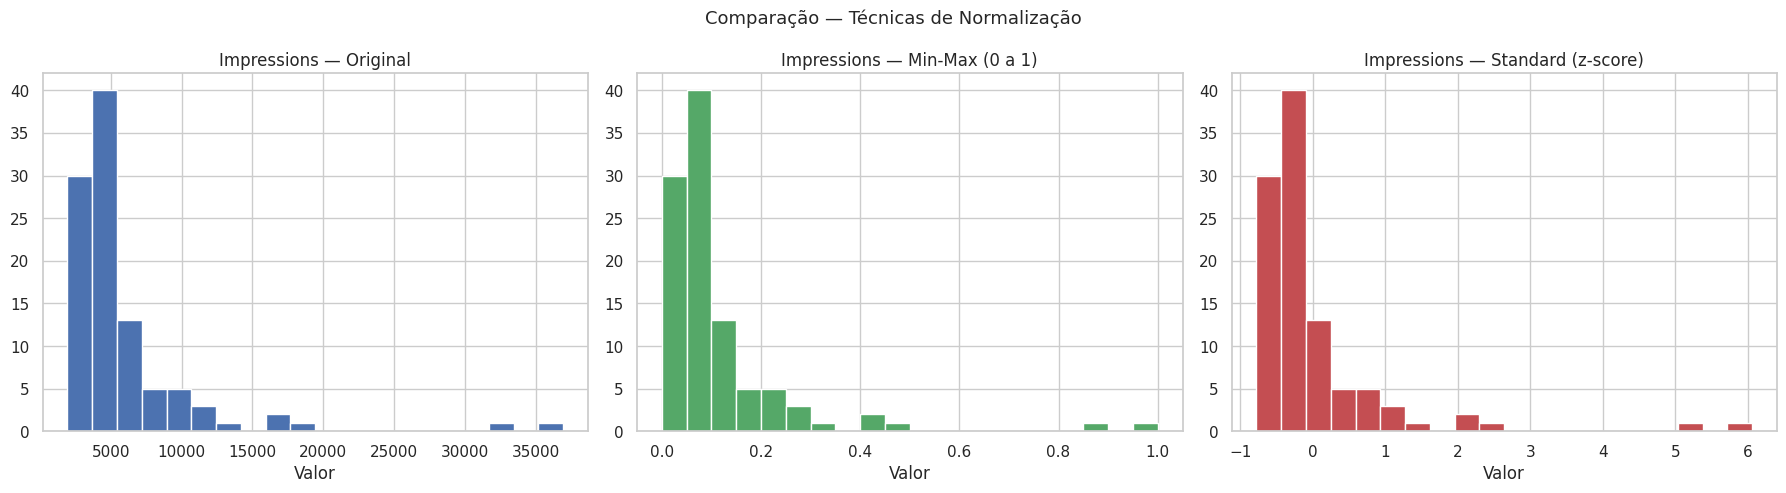

In [259]:
# ─────────────────────────────────────────────────────
# 11.3 Comparação visual — Original vs Min-Max vs Standard
# ─────────────────────────────────────────────────────
col_exemplo = 'Impressions'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df[col_exemplo],            bins=20, color='#4C72B0', edgecolor='white')
axes[0].set_title(f'{col_exemplo} — Original')
axes[0].set_xlabel('Valor')

axes[1].hist(df_minmax[col_exemplo],     bins=20, color='#55A868', edgecolor='white')
axes[1].set_title(f'{col_exemplo} — Min-Max (0 a 1)')
axes[1].set_xlabel('Valor')

axes[2].hist(df_standard[col_exemplo],   bins=20, color='#C44E52', edgecolor='white')
axes[2].set_title(f'{col_exemplo} — Standard (z-score)')
axes[2].set_xlabel('Valor')

plt.suptitle('Comparação — Técnicas de Normalização', fontsize=13)
plt.tight_layout()
plt.show()

In [260]:
# ─────────────────────────────────────────────────────
# 11.4 One-Hot Encoding — main_source
# ─────────────────────────────────────────────────────
# Variável nominal sem ordem — usar One-Hot Encoding
ohe_source = pd.get_dummies(df['main_source'], prefix='source', dtype=int)

print('✅ One-Hot Encoding — main_source')
print(f'Categorias: {df["main_source"].unique().tolist()}')
print(f'Colunas geradas: {ohe_source.columns.tolist()}')
display(ohe_source.head(10))

✅ One-Hot Encoding — main_source
Categorias: ['From Home', 'From Hashtags', 'From Explore']
Colunas geradas: ['source_From Explore', 'source_From Hashtags', 'source_From Home']


,source_From Explore,source_From Hashtags,source_From Home
0,0,0,1
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1
5,0,0,1
6,0,0,1
7,0,0,1
8,0,0,1
9,0,0,1


In [261]:
# ─────────────────────────────────────────────────────
# 11.5 Label Encoding — impressions_category
# ─────────────────────────────────────────────────────
# Variável ordinal com ordem definida — usar Label Encoding
# Baixo=0, Medio=1, Alto=2, Viral=3
ordem = {'Baixo': 0, 'Medio': 1, 'Alto': 2, 'Viral': 3}
df['impressions_category_encoded'] = df['impressions_category'].map(ordem)

print('✅ Label Encoding — impressions_category')
print('Mapeamento aplicado:')
for k, v in ordem.items():
    print(f'   {k} → {v}')

display(df[['impressions_category', 'impressions_category_encoded']].drop_duplicates().sort_values('impressions_category_encoded'))

✅ Label Encoding — impressions_category
Mapeamento aplicado:
   Baixo → 0
   Medio → 1
   Alto → 2
   Viral → 3


,impressions_category,impressions_category_encoded
4,Baixo,0
0,Medio,1
1,Alto,2
40,Viral,3


In [262]:
# ─────────────────────────────────────────────────────
# 11.6 Dataset final — pronto para modelagem
# ─────────────────────────────────────────────────────
# Juntar tudo: numéricas normalizadas + OHE + Label Encoding
df_final = df_minmax[cols_normalizar].copy()
df_final = pd.concat([df_final, ohe_source], axis=1)
df_final['impressions_category_encoded'] = df['impressions_category_encoded']

print(f'✅ Dataset final para modelagem')
print(f'   Shape  : {df_final.shape}')
print(f'   Colunas: {df_final.columns.tolist()}')
display(df_final.head())

# Exportar
df_final.to_csv('/content/Instagram_data_modelagem.csv', index=False)
print('\n✅ Exportado: Instagram_data_modelagem.csv')

✅ Dataset final para modelagem
   Shape  : (102, 19)
   Colunas: ['Impressions', 'From Home', 'From Hashtags', 'From Explore', 'From Other', 'Saves', 'Comments', 'Shares', 'Likes', 'Profile Visits', 'Follows', 'caption_length', 'num_hashtags', 'engagement_rate', 'conversion_rate', 'source_From Explore', 'source_From Hashtags', 'source_From Home', 'impressions_category_encoded']


,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,caption_length,num_hashtags,engagement_rate,conversion_rate,source_From Explore,source_From Hashtags,source_From Home,impressions_category_encoded
0,0.06,0.12,0.08,0.04,0.02,0.07,0.47,0.07,0.19,0.05,0.01,0.09,0.60,0.39,0.03,0,0,1,1
1,0.10,0.13,0.15,0.07,0.03,0.16,0.37,0.19,0.32,0.07,0.04,0.19,0.40,0.51,0.10,0,0,1,2
2,0.06,0.08,0.09,0.00,0.21,0.02,0.58,0.01,0.12,0.10,0.05,0.10,0.40,0.15,0.09,0,0,1,1
3,0.07,0.13,0.04,0.05,0.03,0.14,0.53,0.09,0.30,0.03,0.03,0.21,0.05,0.58,0.16,0,0,1,1
4,0.02,0.05,0.01,0.02,0.01,0.07,0.26,0.05,0.11,0.01,0.00,0.18,0.95,0.60,0.00,0,0,1,0



✅ Exportado: Instagram_data_modelagem.csv


---
## 4. 📈 Estatísticas Descritivas

In [263]:
# Estatísticas das colunas numéricas
pd.set_option('display.float_format', '{:,.2f}'.format)
df[cols_num].describe().T

,count,mean,std,min,25%,50%,75%,max
Impressions,102.00,"5,920.25","5,139.89","1,941.00","3,556.00","4,343.50","6,296.25","36,919.00"
From Home,102.00,"2,496.91","1,588.38","1,133.00","1,923.75","2,216.00","2,605.25","13,473.00"
From Hashtags,102.00,"1,968.28","1,977.30",116.00,753.00,"1,326.00","2,415.75","11,817.00"
From Explore,102.00,"1,178.57","2,797.21",0.00,178.75,337.00,728.50,"17,414.00"
From Other,102.00,184.55,309.10,9.00,40.25,75.00,218.50,"2,547.00"
Saves,102.00,156.55,157.77,22.00,70.50,111.00,173.50,"1,095.00"
Comments,102.00,6.35,3.31,0.00,4.00,6.00,8.00,19.00
Shares,102.00,9.30,10.15,0.00,3.00,6.50,13.00,75.00
Likes,102.00,176.82,85.15,72.00,122.00,157.50,208.75,549.00
Profile Visits,102.00,54.67,93.17,4.00,16.00,24.00,45.75,611.00


In [264]:
# Resumo estatístico completo com métricas adicionais
resumo = pd.DataFrame({
    'Mínimo'    : df[cols_num].min(),
    'Máximo'    : df[cols_num].max(),
    'Média'     : df[cols_num].mean().round(2),
    'Mediana'   : df[cols_num].median(),
    'Desvio Padrão' : df[cols_num].std().round(2),
    'Assimetria': df[cols_num].skew().round(2),
    'Curtose'   : df[cols_num].kurt().round(2),
})
display(resumo)

,Mínimo,Máximo,Média,Mediana,Desvio Padrão,Assimetria,Curtose
Impressions,1941,36919,"5,920.25","4,343.50","5,139.89",3.98,19.42
From Home,1133,13473,"2,496.91","2,216.00","1,588.38",5.40,33.48
From Hashtags,116,11817,"1,968.28","1,326.00","1,977.30",2.50,8.11
From Explore,0,17414,"1,178.57",337.00,"2,797.21",4.44,21.21
From Other,9,2547,184.55,75.00,309.10,5.06,34.23
Saves,22,1095,156.55,111.00,157.77,3.17,13.44
Comments,0,19,6.35,6.00,3.31,0.76,1.89
Shares,0,75,9.30,6.50,10.15,3.34,17.46
Likes,72,549,176.82,157.50,85.15,1.72,4.00
Profile Visits,4,611,54.67,24.00,93.17,3.89,16.92


---
## 5. 🚨 Detecção de Outliers

### 5.1 Boxplot — Visão Geral

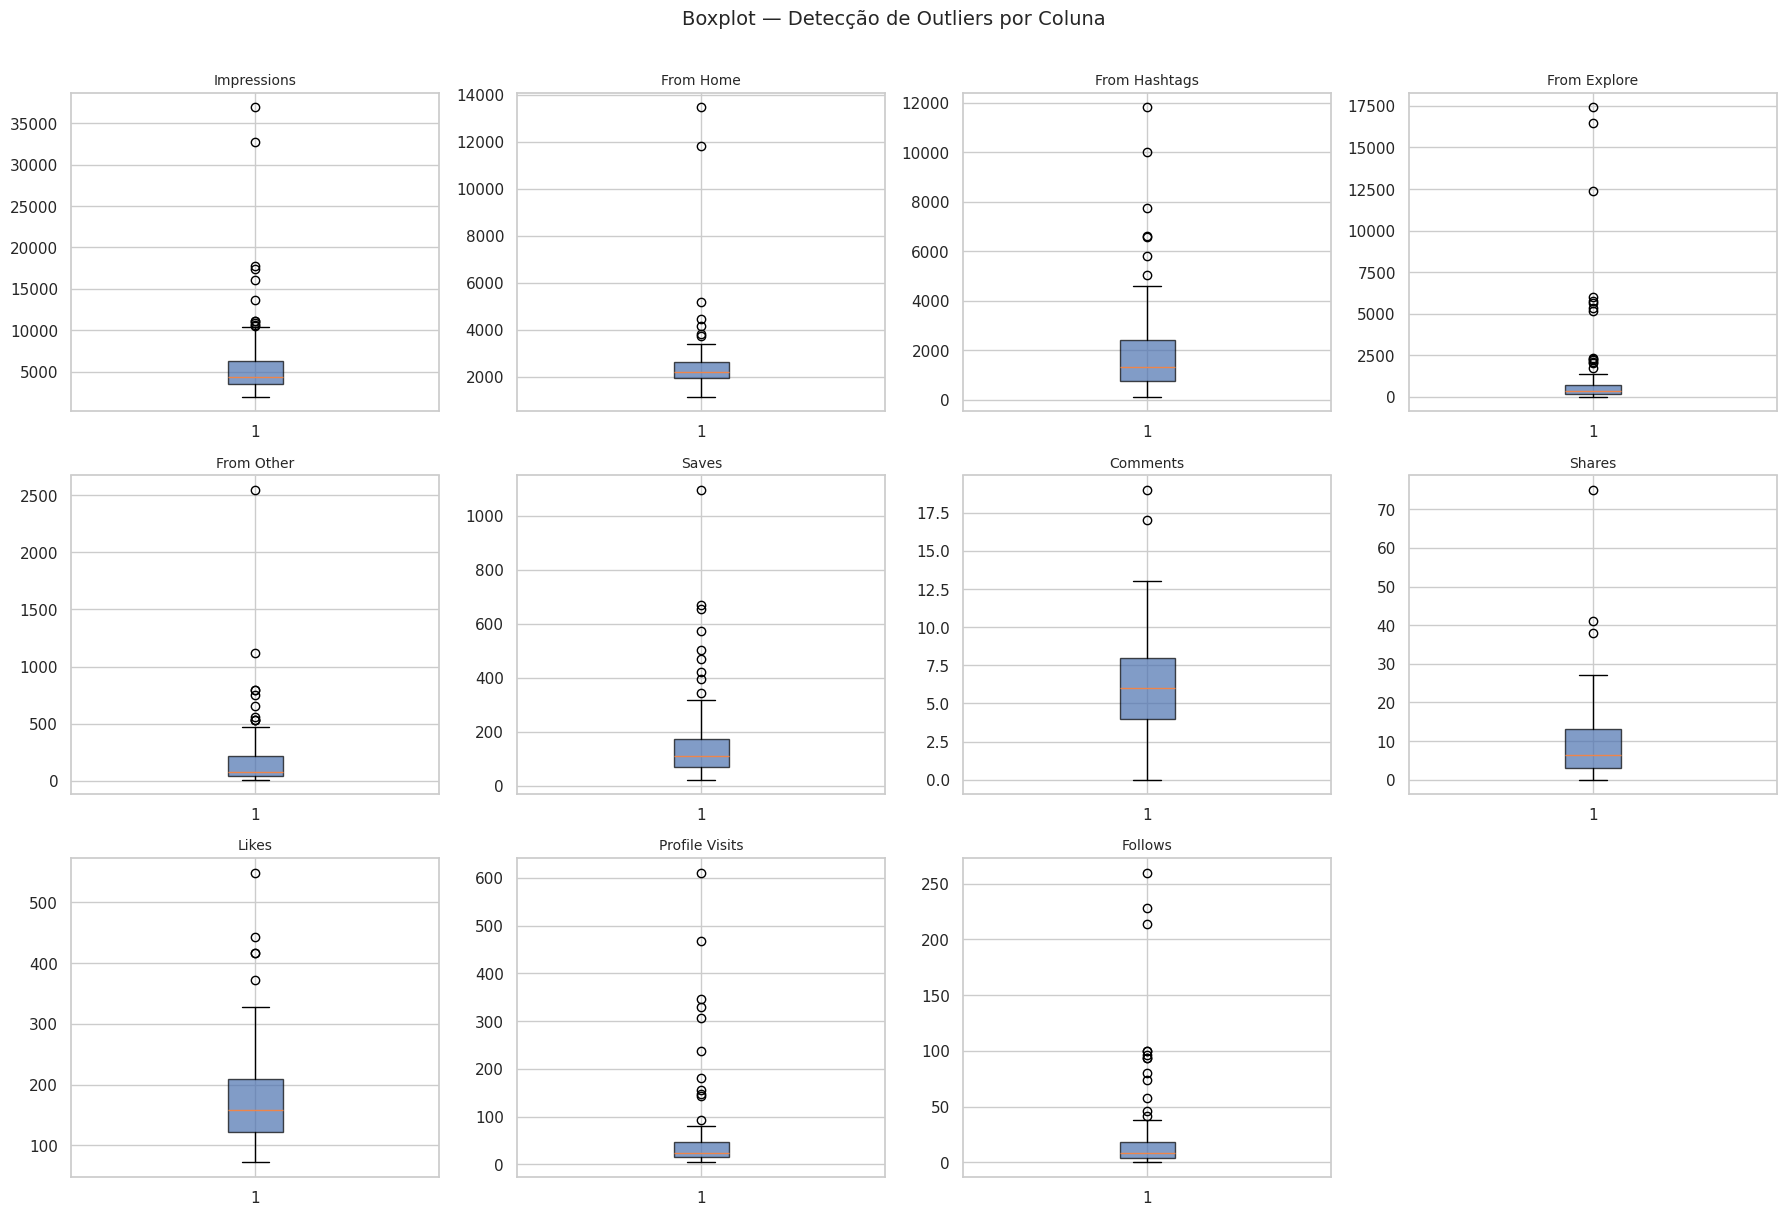

In [265]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.7))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Esconder subplots extras
for j in range(len(cols_num), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot — Detecção de Outliers por Coluna', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Método IQR — Contagem de Outliers

In [266]:
def detectar_outliers_iqr(df, colunas):
    """Detecta outliers usando o método IQR (Interquartile Range)."""
    resultado = []
    for col in colunas:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR
        outliers   = df[(df[col] < limite_inf) | (df[col] > limite_sup)]
        resultado.append({
            'Coluna'        : col,
            'Q1'            : round(Q1, 2),
            'Q3'            : round(Q3, 2),
            'IQR'           : round(IQR, 2),
            'Limite Inf'    : round(limite_inf, 2),
            'Limite Sup'    : round(limite_sup, 2),
            'Qtd Outliers'  : len(outliers),
            '% Outliers'    : round(len(outliers) / len(df) * 100, 2)
        })
    return pd.DataFrame(resultado).set_index('Coluna')

outliers_df = detectar_outliers_iqr(df, cols_num)
display(outliers_df)

,Q1,Q3,IQR,Limite Inf,Limite Sup,Qtd Outliers,% Outliers
Coluna,,,,,,,
Impressions,"3,556.00","6,296.25","2,740.25",-554.38,"10,406.62",11,10.78
From Home,"1,923.75","2,605.25",681.50,901.50,"3,627.50",7,6.86
From Hashtags,753.00,"2,415.75","1,662.75","-1,741.12","4,909.88",7,6.86
From Explore,178.75,728.50,549.75,-645.88,"1,553.12",14,13.73
From Other,40.25,218.50,178.25,-227.12,485.88,10,9.80
Saves,70.50,173.50,103.00,-84.00,328.00,9,8.82
Comments,4.00,8.00,4.00,-2.00,14.00,2,1.96
Shares,3.00,13.00,10.00,-12.00,28.00,3,2.94
Likes,122.00,208.75,86.75,-8.12,338.88,5,4.90


### 5.3 Detalhe dos Outliers — Impressions

In [267]:
# Análise detalhada da coluna com mais outliers
col_analise = 'Impressions'
Q1  = df[col_analise].quantile(0.25)
Q3  = df[col_analise].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_imp = df[(df[col_analise] < lim_inf) | (df[col_analise] > lim_sup)]

print(f'Coluna: {col_analise}')
print(f'Limite inferior : {lim_inf:,.0f}')
print(f'Limite superior : {lim_sup:,.0f}')
print(f'Outliers encontrados: {len(outliers_imp)}')
display(outliers_imp[['Impressions', 'From Home', 'From Hashtags', 'From Explore', 'Likes', 'Follows']])

Coluna: Impressions
Limite inferior : -554
Limite superior : 10,407
Outliers encontrados: 11


,Impressions,From Home,From Hashtags,From Explore,Likes,Follows
40,16062,3144,11817,564,416,94
54,10667,3152,6564,617,297,74
67,10933,3152,6610,623,301,94
76,10493,2106,7761,248,244,32
105,11068,2099,2986,5634,250,34
107,17396,1817,10008,5192,416,260
109,17713,2449,2141,12389,308,96
112,11149,4439,747,5762,210,58
114,13700,5185,3041,5352,373,80
117,32695,11815,3147,17414,549,214


---
## 6. 📉 Análise de Distribuição

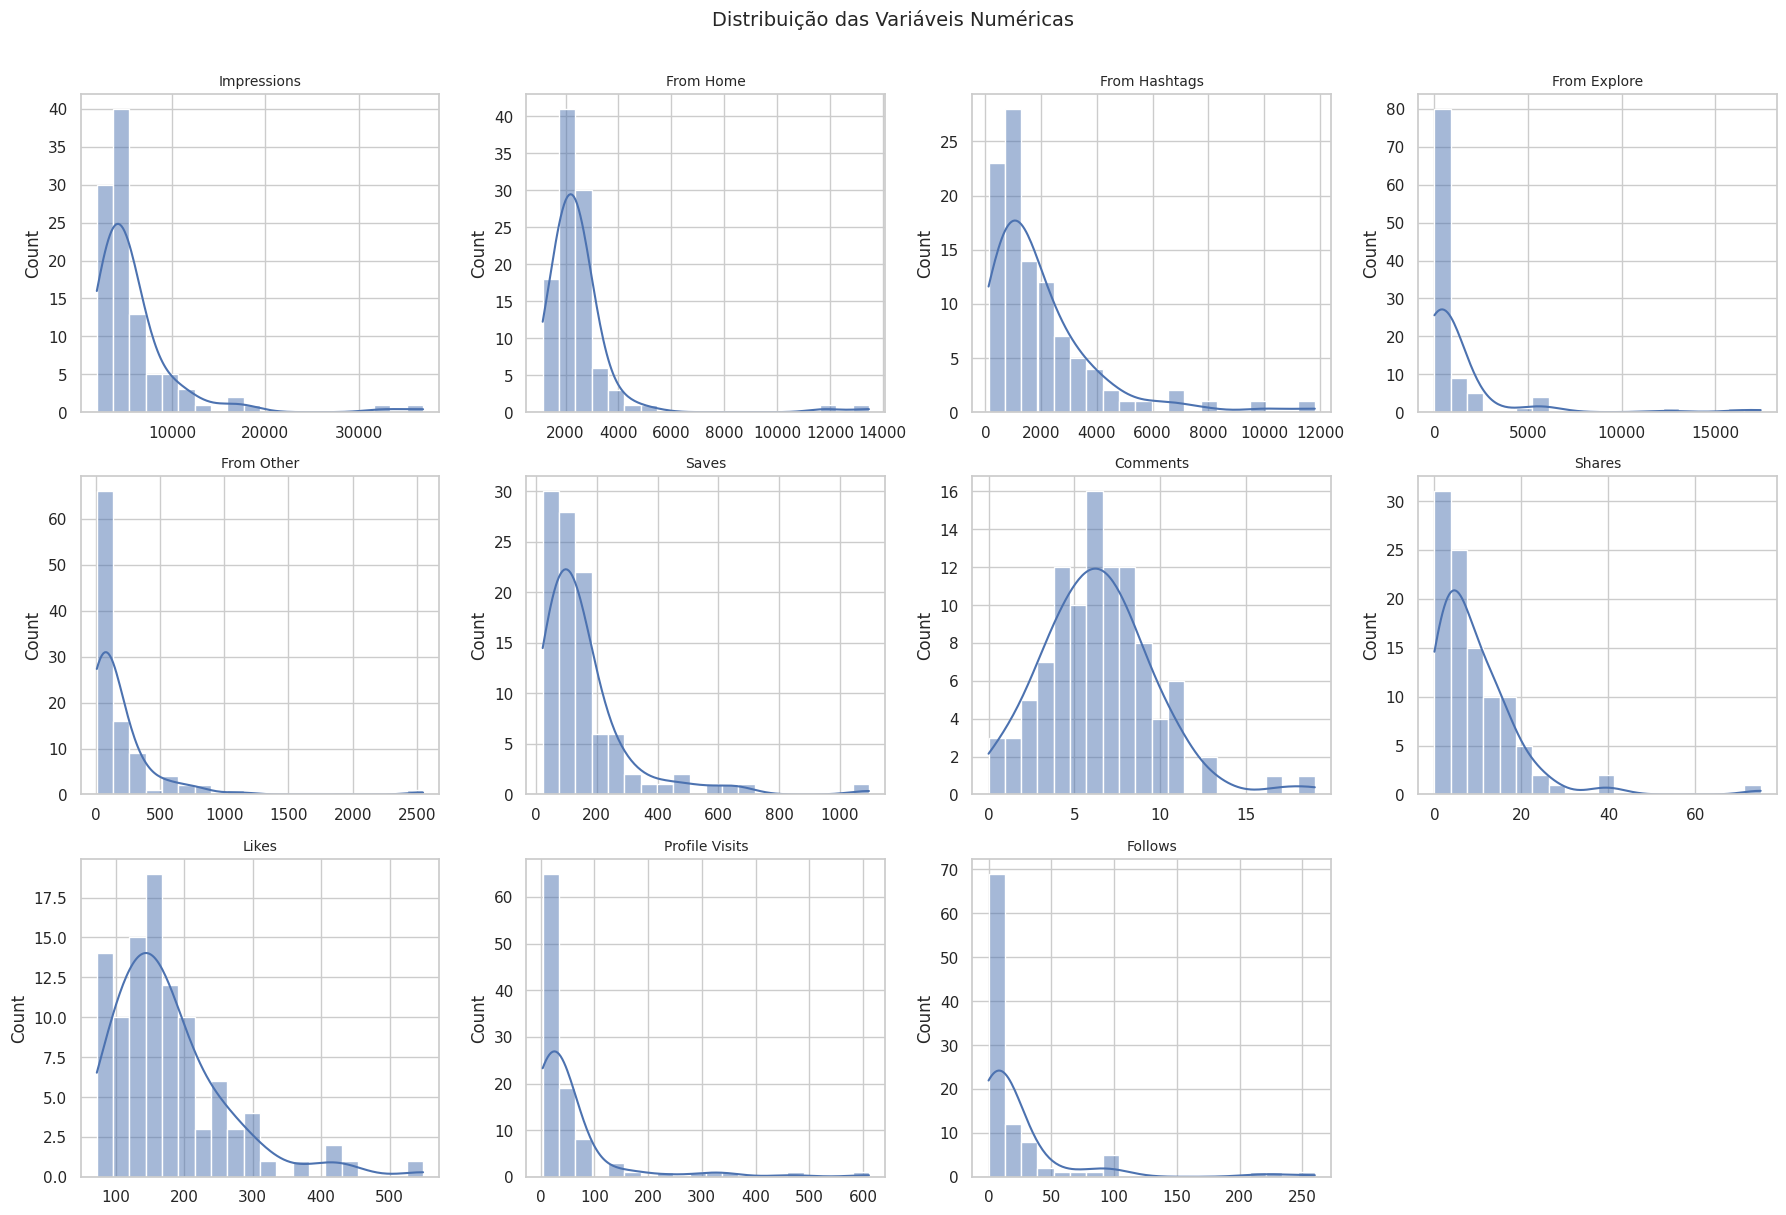

In [268]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#4C72B0', bins=20)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(len(cols_num), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. 🔗 Correlações

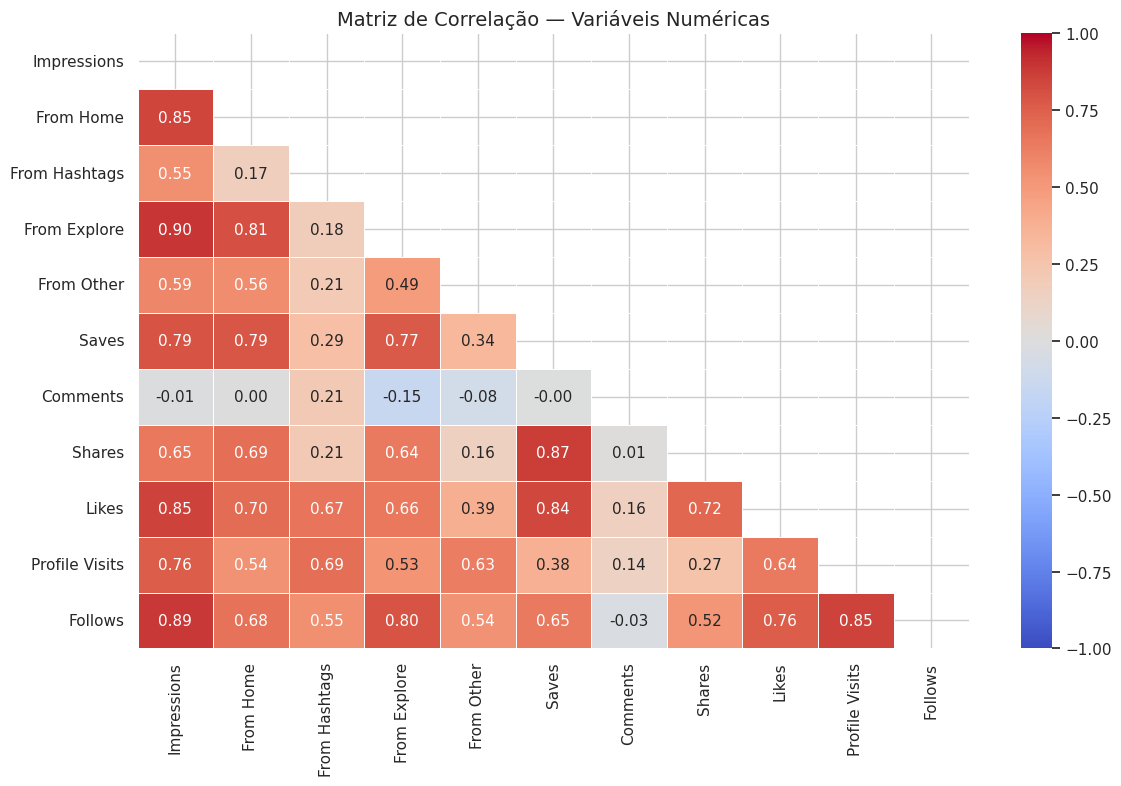

In [269]:
# Heatmap de correlação
corr = df[cols_num].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação — Variáveis Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

In [270]:
# Top correlações com Impressions
print('Top correlações com Impressions:')
display(
    corr['Impressions']
    .drop('Impressions')
    .sort_values(ascending=False)
    .to_frame()
    .rename(columns={'Impressions': 'Correlação'})
    .style.background_gradient(cmap='RdYlGn', vmin=-1, vmax=1)
    .format('{:.4f}')
)

Top correlações com Impressions:


,Correlação
From Explore,0.8950
Follows,0.8899
Likes,0.8530
From Home,0.8502
Saves,0.7914
Profile Visits,0.7627
Shares,0.6549
From Other,0.5866
From Hashtags,0.5473
Comments,-0.0085


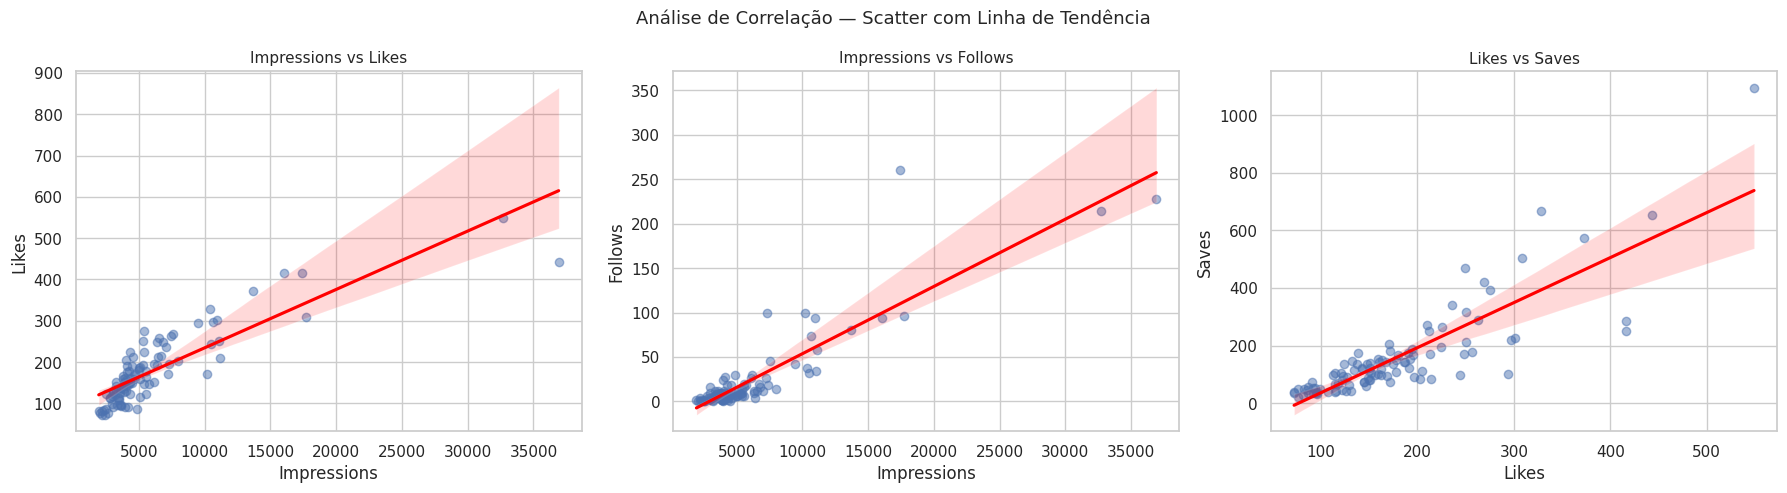

In [271]:
# Scatter — Impressions vs Likes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pares = [('Impressions', 'Likes'),
         ('Impressions', 'Follows'),
         ('Likes',       'Saves')]

for ax, (x, y) in zip(axes, pares):
    sns.regplot(data=df, x=x, y=y, ax=ax,
                scatter_kws={'alpha': 0.5, 'color': '#4C72B0'},
                line_kws={'color': 'red'})
    ax.set_title(f'{x} vs {y}', fontsize=11)

plt.suptitle('Análise de Correlação — Scatter com Linha de Tendência', fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. 📝 Análise de Texto

### 8.1 Comprimento das Captions

Estatísticas do comprimento das Captions:
count   102.00
mean    179.69
std     128.17
min      44.00
25%      87.00
50%     131.00
75%     230.25
max     784.00
Name: caption_length, dtype: float64


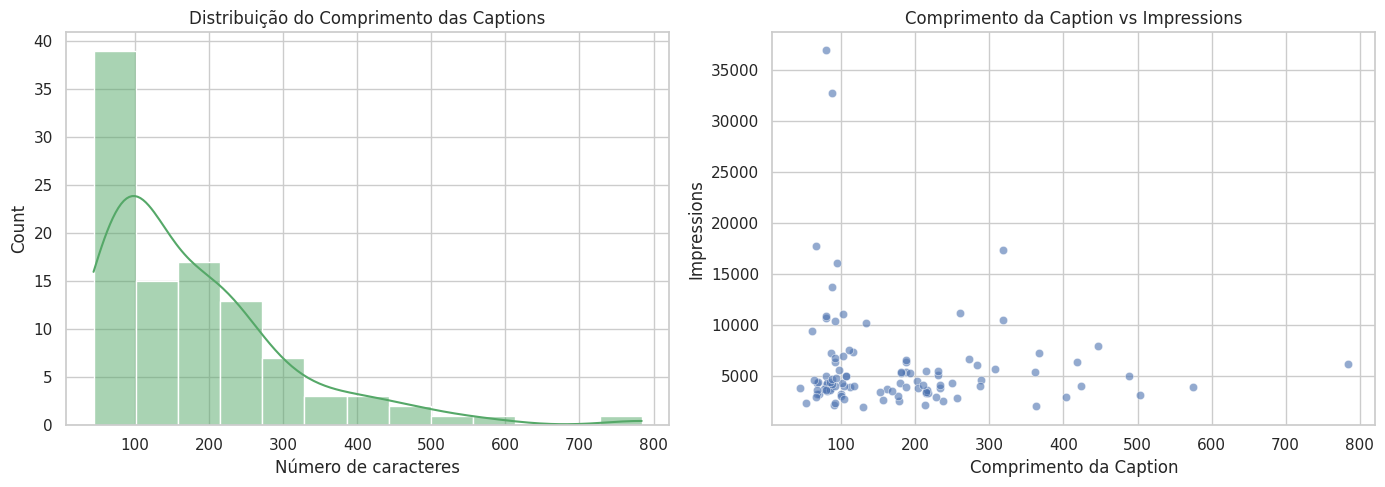

In [272]:
df['caption_length'] = df['Caption'].astype(str).apply(len)

print('Estatísticas do comprimento das Captions:')
print(df['caption_length'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['caption_length'], kde=True, ax=axes[0], color='#55A868')
axes[0].set_title('Distribuição do Comprimento das Captions')
axes[0].set_xlabel('Número de caracteres')

sns.scatterplot(data=df, x='caption_length', y='Impressions', ax=axes[1],
                alpha=0.6, color='#4C72B0')
axes[1].set_title('Comprimento da Caption vs Impressions')
axes[1].set_xlabel('Comprimento da Caption')

plt.tight_layout()
plt.show()

### 8.2 Análise de Hashtags

In [273]:
# Extrair todas as hashtags
todas_hashtags = []
for texto in df['Hashtags'].astype(str):
    tags = [t.strip().lower() for t in texto.split() if t.startswith('#')]
    todas_hashtags.extend(tags)

contagem_tags = Counter(todas_hashtags)
top_tags = pd.DataFrame(contagem_tags.most_common(20),
                         columns=['Hashtag', 'Frequência'])

print(f'Total de hashtags únicas: {len(contagem_tags)}')
display(top_tags)

Total de hashtags únicas: 163


,Hashtag,Frequência
0,#suasaladatech,100
1,#thecleverprogrammer,100
2,#python,93
3,#pythonprogramming,84
4,#pythonprojects,82
5,#machinelearning,81
6,#datascience,79
7,#ai,77
8,#artificialintelligence,75
9,#data,74


In [ ]:
# Gráfico Top 20 Hashtags
plt.figure(figsize=(14, 6))
sns.barplot(data=top_tags, x='Frequência', y='Hashtag',
            palette='Blues_r')
plt.title('Top 20 Hashtags Mais Utilizadas', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# WordCloud das Hashtags
texto_wc = ' '.join(todas_hashtags)
wc = WordCloud(width=900, height=400, background_color='white',
               colormap='Blues', max_words=100).generate(texto_wc)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Hashtags', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Número de hashtags por post
df['num_hashtags'] = df['Hashtags'].astype(str).apply(
    lambda x: len([t for t in x.split() if t.startswith('#')])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['num_hashtags'], kde=True, ax=axes[0], color='#C44E52')
axes[0].set_title('Distribuição — Número de Hashtags por Post')
axes[0].set_xlabel('Quantidade de Hashtags')

sns.scatterplot(data=df, x='num_hashtags', y='Impressions', ax=axes[1],
                alpha=0.6, color='#C44E52')
axes[1].set_title('Número de Hashtags vs Impressions')

plt.tight_layout()
plt.show()

---
## 9. 🛠️ Engenharia de Features

In [ ]:
# Taxa de engajamento
df['engagement_rate'] = (
    (df['Likes'] + df['Comments'] + df['Shares'] + df['Saves'])
    / df['Impressions'] * 100
).round(4)

# Taxa de conversão (Follows / Profile Visits)
df['conversion_rate'] = (
    df['Follows'] / df['Profile Visits'].replace(0, np.nan) * 100
).round(4)

# Origem principal dos acessos
fontes = ['From Home', 'From Hashtags', 'From Explore', 'From Other']
df['main_source'] = df[fontes].idxmax(axis=1)

# Categorizar Impressions
df['impressions_category'] = pd.cut(
    df['Impressions'],
    bins=[0, 3000, 5000, 10000, float('inf')],
    labels=['Baixo', 'Médio', 'Alto', 'Viral']
)

print('✅ Features criadas com sucesso!')
print(f"   engagement_rate    — média: {df['engagement_rate'].mean():.2f}%")
print(f"   conversion_rate    — média: {df['conversion_rate'].mean():.2f}%")
print(f"   main_source        — distribuição:")
print(df['main_source'].value_counts().to_string())
print(f"\n   impressions_category — distribuição:")
print(df['impressions_category'].value_counts().to_string())

In [ ]:
# Visualização das novas features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribuição do Engagement Rate
sns.histplot(df['engagement_rate'], kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribuição — Engagement Rate (%)')
axes[0].set_xlabel('Engagement Rate (%)')

# Origem principal dos acessos
df['main_source'].value_counts().plot(kind='bar', ax=axes[1],
                                       color=['#4C72B0','#55A868','#C44E52','#8172B2'])
axes[1].set_title('Origem Principal dos Acessos')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

# Categoria de Impressions
df['impressions_category'].value_counts().plot(kind='bar', ax=axes[2],
                                                color=['#CCE5FF','#99CAFF','#4C72B0','#1A3A7A'])
axes[2].set_title('Categorias de Impressions')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Engenharia de Features — Novas Variáveis', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Engagement Rate por categoria de Impressions
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='impressions_category', y='engagement_rate',
            palette='Blues')
plt.title('Engagement Rate por Categoria de Impressions')
plt.xlabel('Categoria de Impressions')
plt.ylabel('Engagement Rate (%)')
plt.tight_layout()
plt.show()

---
## 10. 💡 Insights e Conclusões

In [ ]:
# Resumo final do dataset tratado
print('=' * 55)
print('      RESUMO FINAL — INSTAGRAM ANALYTICS')
print('=' * 55)
print(f'  Total de posts analisados : {len(df)}')
print(f'  Total de colunas          : {df.shape[1]}')
print(f'  Valores nulos             : {df.isnull().sum().sum()}')
print(f'  Duplicatas                : {df.duplicated().sum()}')
print('=' * 55)
print('  MÉTRICAS MÉDIAS')
print('-' * 55)
print(f'  Impressions       : {df["Impressions"].mean():>10,.0f}')
print(f'  Likes             : {df["Likes"].mean():>10,.0f}')
print(f'  Saves             : {df["Saves"].mean():>10,.0f}')
print(f'  Comments          : {df["Comments"].mean():>10,.0f}')
print(f'  Shares            : {df["Shares"].mean():>10,.0f}')
print(f'  Profile Visits    : {df["Profile Visits"].mean():>10,.0f}')
print(f'  Follows           : {df["Follows"].mean():>10,.0f}')
print(f'  Engagement Rate   : {df["engagement_rate"].mean():>10.2f}%')
print(f'  Conversion Rate   : {df["conversion_rate"].mean():>10.2f}%')
print('=' * 55)
print('  ORIGEM PRINCIPAL DOS ACESSOS')
print('-' * 55)
for fonte, qtd in df['main_source'].value_counts().items():
    pct = qtd / len(df) * 100
    print(f'  {fonte:<20}: {qtd:>3} posts ({pct:.1f}%)')
print('=' * 55)
print('  DISTRIBUIÇÃO DE IMPRESSIONS')
print('-' * 55)
for cat, qtd in df['impressions_category'].value_counts().sort_index().items():
    pct = qtd / len(df) * 100
    print(f'  {str(cat):<10}: {qtd:>3} posts ({pct:.1f}%)')
print('=' * 55)

In [ ]:
# Exportar dataset tratado
df.to_csv('Instagram_data_tratado.csv', index=False, encoding='utf-8')
print('✅ Dataset tratado exportado: Instagram_data_tratado.csv')